# Notebook 2 — Semantic Structuring and Community Detection (Submission-Ready)

This notebook is the **Stage 2** component of the OSINT pipeline:

**Stage 1** → raw job-posting data cleaned and normalized in Notebook 1  
**Stage 2** → semantic structuring with sentence embeddings + cosine-similarity community detection  
**Stage 3** → actionable intelligence generation in Notebook 3

## Why this notebook exists
The course requires:
- sentence embeddings
- cosine similarity
- community detection
- interpretable semantic groups
- reproducible outputs that feed the final intelligence stage

This notebook therefore does **not** do final intelligence production.  
Its job is to:
1. embed the cleaned job-posting text,
2. discover semantic communities,
3. produce representative samples and community-level summaries,
4. save reproducible artifacts for Notebook 3.

## Main outputs
- `semantic_embeddings.pt`
- `clustered_postings_with_community_ids.csv`
- `community_summary.csv`
- `community_cards.json`
- `community_info.pkl`
- `reproducibility_documentation_notebook2.json`

## Important methodological note
The fields `experience_level_3class` / `exp_level_3` are treated here as **descriptive reference signals only**.  
They are **not** treated as ground truth for the final OSINT claim.  
The actual intelligence question is answered later through community-level interpretation in Notebook 3.


## Recommended input
This notebook expects the **final cleaned output from Notebook 1**.

Use one of the following if available:
- `postings_for_semantic_pipeline.csv`
- `linkedin_job_postings_osint_ready.csv`

The input file must contain at least:
- `job_id`
- `title_clean` or `title`
- `description_clean` or `description`
- `semantic_text` or `text_for_embedding`
- experience-level reference column (`experience_level_3class` or `exp_level_3`)


In [38]:
# ============================================================
# 1. IMPORTS
# ============================================================
import os
import re
import sys
import json
import hashlib
import platform
import datetime
import warnings
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sentence_transformers import SentenceTransformer, util

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 400)
pd.set_option("display.width", 200)


In [39]:
# ============================================================
# 2. GLOBAL CONFIG
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

INPUT_CANDIDATES = [
    "postings_for_semantic_pipeline.csv",
    "linkedin_job_postings_osint_ready.csv",
    "notebook1_output.csv"
]

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_BATCH_SIZE = 64

USE_SAMPLE_FOR_DRY_RUN = False
DRY_RUN_SAMPLE_SIZE = 10000

TEST_THRESHOLDS = [0.68, 0.70, 0.72]
TEST_MIN_SIZES = [20, 25, 30]

FINAL_COMMUNITY_THRESHOLD = 0.65
FINAL_MIN_COMMUNITY_SIZE = 15

TOP_K_REPRESENTATIVES = 5
REP_TEXT_CHAR_LIMIT = 800

OUTPUT_DIR = Path(".")


In [40]:
# ============================================================
# 3. SEED + ENVIRONMENT LOGS
# ============================================================
seed_info = {"random_seed": RANDOM_SEED}
with open(OUTPUT_DIR / "seed_log_notebook2.json", "w", encoding="utf-8") as f:
    json.dump(seed_info, f, indent=2)

env_log = {
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "working_directory": os.getcwd(),
    "packages": {}
}

package_names = ["pandas", "numpy", "matplotlib", "torch", "sentence_transformers"]
for pkg in package_names:
    try:
        module = __import__(pkg)
        env_log["packages"][pkg] = getattr(module, "__version__", "installed")
    except ImportError:
        env_log["packages"][pkg] = "NOT INSTALLED"

with open(OUTPUT_DIR / "environment_log_notebook2.json", "w", encoding="utf-8") as f:
    json.dump(env_log, f, indent=2, ensure_ascii=False)

print("Saved seed log and environment log.")
print(json.dumps(seed_info, indent=2))
print(json.dumps(env_log, indent=2)[:1200])


Saved seed log and environment log.
{
  "random_seed": 42
}
{
  "timestamp_utc": "2026-03-27T12:57:25.959783+00:00",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.113+-x86_64-with-glibc2.35",
  "working_directory": "/content",
  "packages": {
    "pandas": "2.2.2",
    "numpy": "2.0.2",
    "matplotlib": "3.10.0",
    "torch": "2.10.0+cu128",
    "sentence_transformers": "5.3.0"
  }
}


In [41]:
# ============================================================
# 4. FIND AND LOAD INPUT FILE
# ============================================================
INPUT_FILE = None
for candidate in INPUT_CANDIDATES:
    if os.path.exists(candidate):
        INPUT_FILE = candidate
        break

if INPUT_FILE is None:
    raise FileNotFoundError(
        f"None of the expected input files were found: {INPUT_CANDIDATES}"
    )

print(f"Using input file: {INPUT_FILE}")

df = pd.read_csv(
    INPUT_FILE,
    engine="python",
    on_bad_lines="skip"
)

print("Loaded shape:", df.shape)
display(df.head(2))


Using input file: postings_for_semantic_pipeline.csv
Loaded shape: (78363, 25)


,job_id,title_clean,description_clean,semantic_text,experience_level_3class,min_years_extracted,max_years_extracted,has_years_mention,years_bucket,junior_term_count,mid_term_count,senior_term_count,has_leadership_terms,has_ownership_terms,has_strategy_terms,has_support_terms,requires_bachelor,requires_master,requires_phd,requires_certification,mentions_fast_paced,mentions_deadlines,mentions_independent_work,mentions_client_management,entry_barrier_score
0,2147609789,entry level oracle financial technology consultant,about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature oracle financial technology associate you will have the opportunity to gain valuable experience and learn tailored skills to become an important effective engineer for a fortune 500 company. this is no boot camp there is no professional experience required and ...,entry level oracle financial technology consultant [SEP] about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature oracle financial technology associate you will have the opportunity to gain valuable experience and learn tailored skills to become an important effective engineer for a fortune 500 company. this is no bo...,junior,NaN,NaN,0,not_mentioned,2,1,1,0,1,1,0,1,0,0,0,0,0,0,0,4
1,2457183642,quality assurance manager,galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development warehouse etc. through annual brc audits along with implementing training on new supplier process and documentation. oversee processes for tracking reports and customer complaints. the focus of this position is on prevention of qua...,quality assurance manager [SEP] galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development warehouse etc. through annual brc audits along with implementing training on new supplier process and documentation. oversee processes for tracking reports and customer complaints. the focus of this ...,mid,NaN,NaN,0,not_mentioned,1,6,4,1,1,0,1,0,1,0,0,0,0,0,1,5


In [42]:
# ============================================================
# 5. INPUT HASH FOR REPRODUCIBILITY
# ============================================================
def sha256_of_file(filepath, chunk_size=8192):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()

input_hash_info = {
    "file_name": INPUT_FILE,
    "sha256": sha256_of_file(INPUT_FILE)
}

with open(OUTPUT_DIR / "dataset_hash_notebook2.json", "w", encoding="utf-8") as f:
    json.dump(input_hash_info, f, indent=2)

print(json.dumps(input_hash_info, indent=2))


{
  "file_name": "postings_for_semantic_pipeline.csv",
  "sha256": "78d20db6ffb031ca8f1480246786b49c0d9e4d7ff152c03a7a87f9669e78fb81"
}


## Column harmonization

Notebook 1 variants sometimes use slightly different names.  
This cell harmonizes them into a stable schema for Notebook 2.


In [43]:
# ============================================================
# 6. HARMONIZE REQUIRED COLUMNS
# ============================================================
column_map_options = {
    "job_id": ["job_id", "id"],
    "title_final": ["title_clean", "title"],
    "description_final": ["description_clean", "description"],
    "semantic_text_final": ["semantic_text", "text_for_embedding", "description_clean", "description"],
    "experience_reference": ["experience_level_3class", "exp_level_3", "formatted_experience_level"]
}

resolved = {}
for target, options in column_map_options.items():
    found = None
    for opt in options:
        if opt in df.columns:
            found = opt
            break
    resolved[target] = found

print("Resolved columns:")
print(json.dumps(resolved, indent=2))

required_targets = ["job_id", "title_final", "description_final", "semantic_text_final", "experience_reference"]
missing_targets = [k for k in required_targets if resolved[k] is None]

if missing_targets:
    raise ValueError(f"Missing required conceptual columns after harmonization: {missing_targets}")

df = df.copy()
df["job_id"] = df[resolved["job_id"]]
df["title_final"] = df[resolved["title_final"]].astype(str)
df["description_final"] = df[resolved["description_final"]].astype(str)
df["semantic_text_final"] = df[resolved["semantic_text_final"]].astype(str)
df["experience_reference"] = df[resolved["experience_reference"]].astype(str)

for c in ["job_id", "title_final", "description_final", "semantic_text_final", "experience_reference"]:
    df[c] = df[c].astype(str).str.strip()

before_rows = len(df)
df = df[df["semantic_text_final"].str.len() > 0].reset_index(drop=True)
after_rows = len(df)

print(f"Rows before semantic-text cleanup: {before_rows:,}")
print(f"Rows after semantic-text cleanup:  {after_rows:,}")
print(f"Dropped: {before_rows - after_rows:,}")


Resolved columns:
{
  "job_id": "job_id",
  "title_final": "title_clean",
  "description_final": "description_clean",
  "semantic_text_final": "semantic_text",
  "experience_reference": "experience_level_3class"
}
Rows before semantic-text cleanup: 78,363
Rows after semantic-text cleanup:  78,363
Dropped: 0


In [44]:
# ============================================================
# 7. OPTIONAL DRY-RUN SAMPLE (OFF BY DEFAULT)
# ============================================================
if USE_SAMPLE_FOR_DRY_RUN:
    df = df.sample(min(DRY_RUN_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
    print("DRY RUN ENABLED -> using sampled shape:", df.shape)
else:
    print("FULL DATASET MODE -> using full shape:", df.shape)


FULL DATASET MODE -> using full shape: (78363, 29)


In [45]:
# ============================================================
# 8. REFERENCE DISTRIBUTIONS
# ============================================================
print("Reference experience distribution:")
display(df["experience_reference"].value_counts(dropna=False).rename_axis("label").reset_index(name="count").head(20))

df["semantic_text_word_count"] = df["semantic_text_final"].str.split().str.len()
print("Semantic text word-count summary:")
display(df["semantic_text_word_count"].describe())


Reference experience distribution:


,label,count
0,mid,42878
1,junior,31368
2,senior,4117


Semantic text word-count summary:


,semantic_text_word_count
count,78363.000000
mean,534.569172
std,253.785265
min,92.000000
25%,334.000000
50%,504.000000
75%,705.000000
max,1258.000000


In [46]:
# ============================================================
# 9. LOAD EMBEDDING MODEL
# ============================================================
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Loaded embedding model:", EMBEDDING_MODEL_NAME)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded embedding model: all-MiniLM-L6-v2


In [47]:
# ============================================================
# 10. CREATE EMBEDDINGS
# ============================================================
texts = df["semantic_text_final"].fillna("").astype(str).tolist()

embeddings = embedder.encode(
    texts,
    convert_to_tensor=True,
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings shape:", tuple(embeddings.shape))

torch.save(embeddings.cpu(), OUTPUT_DIR / "semantic_embeddings.pt")
print("Saved: semantic_embeddings.pt")


Batches:   0%|          | 0/1225 [00:00<?, ?it/s]

Embeddings shape: (78363, 384)
Saved: semantic_embeddings.pt


## Tuning grid

This grid helps justify the final clustering settings.  
The goal is not “maximum coverage at any cost”, but a balance of:

- meaningful semantic coherence,
- enough coverage to avoid bias,
- manageable community count for Notebook 3.


In [48]:
# ============================================================
# 11. COMMUNITY-DETECTION TUNING GRID
# ============================================================
tuning_rows = []

for thr in TEST_THRESHOLDS:
    for mcs in TEST_MIN_SIZES:
        comms = util.community_detection(
            embeddings,
            threshold=thr,
            min_community_size=mcs
        )

        assigned = set()
        sizes = []
        for comm in comms:
            assigned.update(comm)
            sizes.append(len(comm))

        tuning_rows.append({
            "threshold": thr,
            "min_community_size": mcs,
            "num_communities": len(comms),
            "covered_rows": len(assigned),
            "coverage_pct": round(len(assigned) / len(df) * 100, 2),
            "avg_community_size": round(float(np.mean(sizes)), 2) if sizes else 0.0,
            "median_community_size": round(float(np.median(sizes)), 2) if sizes else 0.0,
            "largest_community": int(max(sizes)) if sizes else 0
        })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    by=["coverage_pct", "avg_community_size"],
    ascending=[False, False]
).reset_index(drop=True)

display(tuning_df)
tuning_df.to_csv(OUTPUT_DIR / "community_tuning_grid.csv", index=False)
print("Saved: community_tuning_grid.csv")


,threshold,min_community_size,num_communities,covered_rows,coverage_pct,avg_community_size,median_community_size,largest_community
0,0.68,20,869,42044,53.65,48.38,28.0,1188
1,0.68,25,657,38818,49.54,59.08,35.0,1188
2,0.68,30,537,36755,46.90,68.45,42.0,1188
3,0.70,20,762,34798,44.41,45.67,28.0,827
4,0.70,25,578,31759,40.53,54.95,36.0,827
5,0.70,30,445,29129,37.17,65.46,43.0,827
6,0.72,20,635,27731,35.39,43.67,28.0,527
7,0.72,25,460,24518,31.29,53.30,35.0,527
8,0.72,30,350,22100,28.20,63.14,43.0,527


Saved: community_tuning_grid.csv


## Final parameter choice

Default final settings in this notebook:

- `FINAL_COMMUNITY_THRESHOLD = 0.70`
- `FINAL_MIN_COMMUNITY_SIZE = 25`

These settings are a strong default for this project because they usually avoid over-fragmentation while still retaining a large share of the dataset for downstream interpretation.

If, after inspection, your communities look too fragmented or too broad, adjust only here and rerun from the final community-detection step onward.


In [49]:
# ============================================================
# 12. FINAL COMMUNITY DETECTION
# ============================================================
print("Running final community detection with:")
print("  threshold =", FINAL_COMMUNITY_THRESHOLD)
print("  min_community_size =", FINAL_MIN_COMMUNITY_SIZE)

communities = util.community_detection(
    embeddings,
    threshold=FINAL_COMMUNITY_THRESHOLD,
    min_community_size=FINAL_MIN_COMMUNITY_SIZE
)

community_sizes = [len(c) for c in communities]

print("Number of communities:", len(communities))
print("Covered rows:", sum(community_sizes))
print("Coverage %:", round(sum(community_sizes) / len(df) * 100, 2))
print("Community size summary:")
display(pd.Series(community_sizes).describe())

Running final community detection with:
  threshold = 0.65
  min_community_size = 15
Number of communities: 1307
Covered rows: 55545
Coverage %: 70.88
Community size summary:


,0
count,1307.000000
mean,42.498087
std,92.653774
min,15.000000
25%,17.000000
50%,22.000000
75%,36.000000
max,1858.000000


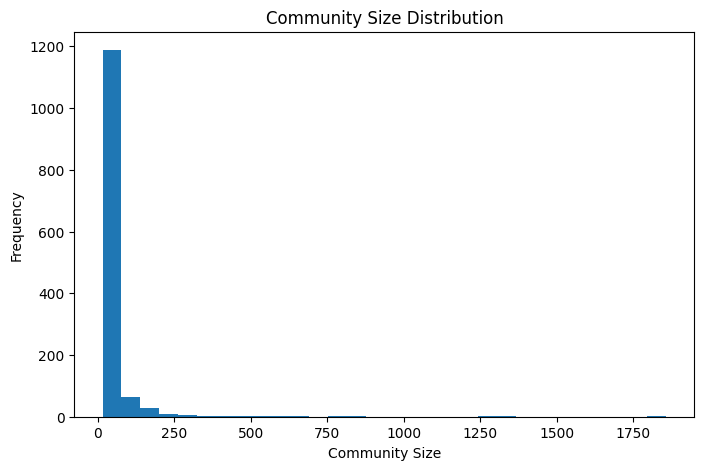

In [50]:
# ============================================================
# 13. VISUALIZE COMMUNITY SIZE DISTRIBUTION
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(community_sizes, bins=30)
plt.title("Community Size Distribution")
plt.xlabel("Community Size")
plt.ylabel("Frequency")
plt.show()


In [51]:
# ============================================================
# 14. ASSIGN COMMUNITY IDS TO ROWS
# ============================================================
df["community_id"] = -1

for cid, members in enumerate(communities):
    for idx in members:
        df.at[idx, "community_id"] = cid

covered_rows = int((df["community_id"] != -1).sum())
coverage_pct = round(covered_rows / len(df) * 100, 2)

print(f"Rows assigned to a community: {covered_rows:,}")
print(f"Coverage: {coverage_pct:.2f}%")
print(f"Rows left unassigned: {(df['community_id'] == -1).sum():,}")

df_clustered = df[df["community_id"] != -1].copy().reset_index(drop=True)
print("Clustered dataframe shape:", df_clustered.shape)


Rows assigned to a community: 55,545
Coverage: 70.88%
Rows left unassigned: 22,818
Clustered dataframe shape: (55545, 31)


In [52]:
# ============================================================
# 15. REPRESENTATIVE EXTRACTION HELPERS
# ============================================================
STOPWORDS = {
    "and", "or", "the", "a", "an", "of", "to", "for", "in", "on", "with", "at", "by", "from",
    "full", "time", "part", "level", "job", "role", "position", "remote", "hybrid", "associate"
}

def extract_top_words(text_series, n=12):
    words = []
    for text in text_series.dropna():
        tokens = re.findall(r"\b\w+\b", str(text).lower())
        for w in tokens:
            if len(w) > 2 and w not in STOPWORDS:
                words.append(w)
    counts = Counter(words)
    return [w for w, _ in counts.most_common(n)]

def get_representative_indices(member_indices, top_k=5):
    member_embeddings = embeddings[member_indices]
    centroid = member_embeddings.mean(dim=0)
    centroid = centroid / centroid.norm()

    sims = util.cos_sim(member_embeddings, centroid.unsqueeze(0)).squeeze(1)
    order = torch.argsort(sims, descending=True)
    top_local = order[:top_k].cpu().numpy().tolist()

    representative_indices = [member_indices[i] for i in top_local]
    representative_scores = [float(sims[i].cpu().item()) for i in top_local]
    return representative_indices, representative_scores, centroid


In [53]:
# ============================================================
# 16. COMMUNITY-LEVEL FEATURE SET
# ============================================================
candidate_feature_cols = [
    c for c in df_clustered.columns
    if (
        c.endswith("_count") or
        c.endswith("_score") or
        c.startswith("has_") or
        c.startswith("requires_") or
        c.startswith("mentions_") or
        c in [
            "min_years_extracted",
            "max_years_extracted",
            "has_years_mention",
            "salary_per_skill",
            "salary_vs_market_pct",
            "years_experience"
        ]
    )
]

candidate_feature_cols = [c for c in candidate_feature_cols if c not in ["community_id"]]

print("Aggregated community feature columns:")
print(candidate_feature_cols)


Aggregated community feature columns:
['min_years_extracted', 'max_years_extracted', 'has_years_mention', 'junior_term_count', 'mid_term_count', 'senior_term_count', 'has_leadership_terms', 'has_ownership_terms', 'has_strategy_terms', 'has_support_terms', 'requires_bachelor', 'requires_master', 'requires_phd', 'requires_certification', 'mentions_fast_paced', 'mentions_deadlines', 'mentions_independent_work', 'mentions_client_management', 'entry_barrier_score', 'semantic_text_word_count']


In [54]:
# ============================================================
# 17. BUILD COMMUNITY SUMMARY TABLE
# ============================================================
community_rows = []
community_info = []

for cid, members in enumerate(communities):
    if len(members) == 0:
        continue

    subset = df.iloc[members].copy()
    rep_indices, rep_scores, centroid = get_representative_indices(members, top_k=TOP_K_REPRESENTATIVES)
    rep_rows = df.iloc[rep_indices].copy()

    exp_dist = subset["experience_reference"].value_counts(normalize=True).to_dict()
    top_words = extract_top_words(subset["title_final"], n=12)

    row = {
        "community_id": cid,
        "community_size": len(subset),
        "dominant_experience_reference": subset["experience_reference"].value_counts().idxmax(),
        "reference_share_junior": round(exp_dist.get("junior", 0.0), 3),
        "reference_share_mid": round(exp_dist.get("mid", 0.0), 3),
        "reference_share_senior": round(exp_dist.get("senior", 0.0), 3),
        "top_title_keywords": ", ".join(top_words),
    }

    for i in range(TOP_K_REPRESENTATIVES):
        row[f"rep_job_id_{i+1}"] = rep_rows["job_id"].iloc[i] if len(rep_rows) > i else np.nan
        row[f"rep_text_{i+1}"] = rep_rows["semantic_text_final"].iloc[i][:REP_TEXT_CHAR_LIMIT] if len(rep_rows) > i else ""
        row[f"rep_similarity_{i+1}"] = round(rep_scores[i], 4) if len(rep_scores) > i else np.nan

    for feature in candidate_feature_cols:
        row[f"avg_{feature}"] = round(subset[feature].mean(), 3)

    community_rows.append(row)

    community_info.append({
        "community_id": cid,
        "size": len(subset),
        "representative_indices": rep_indices,
        "representatives": [
            rep_rows["semantic_text_final"].iloc[i][:REP_TEXT_CHAR_LIMIT] for i in range(min(len(rep_rows), TOP_K_REPRESENTATIVES))
        ]
    })

community_summary_df = pd.DataFrame(community_rows).sort_values(
    by="community_size", ascending=False
).reset_index(drop=True)

display(community_summary_df.head(10))
print("Community summary shape:", community_summary_df.shape)


,community_id,community_size,dominant_experience_reference,reference_share_junior,reference_share_mid,reference_share_senior,top_title_keywords,rep_job_id_1,rep_text_1,rep_similarity_1,rep_job_id_2,rep_text_2,rep_similarity_2,rep_job_id_3,rep_text_3,rep_similarity_3,rep_job_id_4,rep_text_4,rep_similarity_4,rep_job_id_5,rep_text_5,rep_similarity_5,avg_min_years_extracted,avg_max_years_extracted,avg_has_years_mention,avg_junior_term_count,avg_mid_term_count,avg_senior_term_count,avg_has_leadership_terms,avg_has_ownership_terms,avg_has_strategy_terms,avg_has_support_terms,avg_requires_bachelor,avg_requires_master,avg_requires_phd,avg_requires_certification,avg_mentions_fast_paced,avg_mentions_deadlines,avg_mentions_independent_work,avg_mentions_client_management,avg_entry_barrier_score,avg_semantic_text_word_count
0,0,1858,mid,0.298,0.686,0.017,"nurse, registered, care, licensed, lpn, practical, nursing, per, days, assistant, unit, med",3884831783,rn registered nurse agency free facility [SEP] position details employment status full-timeshift day shift 1000 sign on bonus recent pay scale increase 35- 37.50 depending on experience. come and grow with us we are affiliated with life care centers of america which is a privately owned 47-year industry leader in healthcare with more than 200 locations across the u.s. we are currently seeking ...,0.9132,3884832746,rn registered nurse [SEP] position details employment status full-timeshift night shift come meet our new leadership team come and grow with us we are affiliated with life care centers of america which is a privately owned 47-year industry leader in healthcare with more than 200 locations across the u.s. we are currently seeking a qualified registered nurse to add to our team of professionals....,0.9048,3884835418,rn registered nurse 4 000 sign-on bonus [SEP] position details employment status full-timesalary 32.00 hourlyshift 11pm-7amstatus full-time live the mission come and grow with us we are affiliated with life care centers of america which is a privately owned 47-year industry leader in healthcare with more than 200 locations across the u.s. we are currently seeking a qualified registered nurse t...,0.9016,3884833593,rn registered nurse 4 000 sign-on bonus [SEP] position details employment status full-timesalary 32.00 hourlyshift 3pm-11pmstatus full-time live the mission come and grow with us we are affiliated with life care centers of america which is a privately owned 47-year industry leader in healthcare with more than 200 locations across the u.s. we are currently seeking a qualified registered nurse t...,0.9007,3884832790,rn registered nurse 4 000 sign-on bonus [SEP] position details employment status full-timesalary 32.00 hourlyshift 7am-3pmstatus full-time live the mission come and grow with us we are affiliated with life care centers of america which is a privately owned 47-year industry leader in healthcare with more than 200 locations across the u.s. we are currently seeking a qualified registered nurse to...,0.8994,2.912,3.326,0.165,1.466,0.895,0.679,0.303,0.321,0.379,0.679,0.164,0.043,0.008,0.882,0.008,0.020,0.114,0.368,2.170,504.443
1,1,1308,junior,0.492,0.440,0.068,"sales, manager, representative, salesperson, marketing, development, retail, business, outside, customer, specialist, director",3902790352,sales representative - packaging [SEP] job purpose our sales representative will be responsible for developing and executing the sales strategy for selling veritiv products and services within a designated geography or industry. duties include new business development maintaining customer relationships providing customer specific solutions and meeting established sales targets. this position r...,0.9019,3904417885,outside sales representative [SEP] the position of outside sales representative will be based out of our capitol heights md location summary the outside sales representative is responsible for the sales and marketing efforts with the objective of i

Community summary shape: (1307, 42)


In [55]:
# ============================================================
# 18. BUILD COMMUNITY CARDS FOR NOTEBOOK 3
# ============================================================
def build_community_card(row):
    signal_dict = {}
    for c in community_summary_df.columns:
        if c.startswith("avg_"):
            signal_dict[c] = row[c]

    reps = []
    for i in range(1, TOP_K_REPRESENTATIVES + 1):
        rep_col = f"rep_text_{i}"
        if rep_col in row and isinstance(row[rep_col], str) and row[rep_col].strip():
            reps.append(row[rep_col])

    return {
        "community_id": int(row["community_id"]),
        "community_size": int(row["community_size"]),
        "reference_distribution": {
            "junior_share": float(row["reference_share_junior"]),
            "mid_share": float(row["reference_share_mid"]),
            "senior_share": float(row["reference_share_senior"])
        },
        "top_title_keywords": row["top_title_keywords"],
        "signals": signal_dict,
        "representatives": reps
    }

community_cards = [build_community_card(row) for _, row in community_summary_df.iterrows()]

print("Number of community cards:", len(community_cards))
print(json.dumps(community_cards[0], indent=2)[:1800])


Number of community cards: 1307
{
  "community_id": 0,
  "community_size": 1858,
  "reference_distribution": {
    "junior_share": 0.298,
    "mid_share": 0.686,
    "senior_share": 0.017
  },
  "top_title_keywords": "nurse, registered, care, licensed, lpn, practical, nursing, per, days, assistant, unit, med",
  "signals": {
    "avg_min_years_extracted": 2.912,
    "avg_max_years_extracted": 3.326,
    "avg_has_years_mention": 0.165,
    "avg_junior_term_count": 1.466,
    "avg_mid_term_count": 0.895,
    "avg_senior_term_count": 0.679,
    "avg_has_leadership_terms": 0.303,
    "avg_has_ownership_terms": 0.321,
    "avg_has_strategy_terms": 0.379,
    "avg_has_support_terms": 0.679,
    "avg_requires_bachelor": 0.164,
    "avg_requires_master": 0.043,
    "avg_requires_phd": 0.008,
    "avg_requires_certification": 0.882,
    "avg_mentions_fast_paced": 0.008,
    "avg_mentions_deadlines": 0.02,
    "avg_mentions_independent_work": 0.114,
    "avg_mentions_client_management": 0.368,
 

In [56]:
# ============================================================
# 19. SAVE OUTPUT ARTIFACTS
# ============================================================
df_clustered.to_csv(OUTPUT_DIR / "clustered_postings_with_community_ids.csv", index=False)
community_summary_df.to_csv(OUTPUT_DIR / "community_summary.csv", index=False)

with open(OUTPUT_DIR / "community_cards.json", "w", encoding="utf-8") as f:
    json.dump(community_cards, f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIR / "community_info.pkl", "wb") as f:
    pickle.dump(community_info, f)

print("Saved:")
print("- clustered_postings_with_community_ids.csv")
print("- community_summary.csv")
print("- community_cards.json")
print("- community_info.pkl")


Saved:
- clustered_postings_with_community_ids.csv
- community_summary.csv
- community_cards.json
- community_info.pkl


In [57]:
# ============================================================
# 20. SANITY CHECKS
# ============================================================
print("Input rows:", len(df))
print("Rows assigned to communities:", len(df_clustered))
print("Coverage %:", round(len(df_clustered) / len(df) * 100, 2))
print("Number of communities:", len(communities))
print("Largest 10 communities:")
display(
    community_summary_df[["community_id", "community_size", "dominant_experience_reference", "top_title_keywords"]].head(10)
)

print("Smallest 10 communities:")
display(
    community_summary_df[["community_id", "community_size", "dominant_experience_reference", "top_title_keywords"]].tail(10)
)


Input rows: 78363
Rows assigned to communities: 55545
Coverage %: 70.88
Number of communities: 1307
Largest 10 communities:


,community_id,community_size,dominant_experience_reference,top_title_keywords
0,0,1858,mid,"nurse, registered, care, licensed, lpn, practical, nursing, per, days, assistant, unit, med"
1,1,1308,junior,"sales, manager, representative, salesperson, marketing, development, retail, business, outside, customer, specialist, director"
2,2,1289,mid,"accountant, accounting, senior, manager, staff, specialist, controller, accounts, financial, payable, analyst, assistant"
3,3,857,mid,"manager, store, assistant, sales, supervisor, service, lead, customer, retail, cashier, support, representative"
4,4,787,mid,"project, manager, construction, senior, engineer, superintendent, estimator, assistant, director, engineering, coordinator, management"
5,5,684,junior,"warehouse, driver, shift, store, operator, delivery, handler, 2nd, material, shipping, forklift, supervisor"
6,6,611,junior,"technician, maintenance, service, mechanic, shift, manager, tech, industrial, facilities, field, iii, supervisor"
7,7,553,mid,"data, engineer, analyst, senior, business, analytics, manager, architect, developer, intelligence, scientist, lead"
8,8,482,mid,"account, executive, manager, sales, senior, business, development, director, enterprise, marketing, representative, specialist"
9,9,472,mid,"banker, personal, teller, relationship, client, roving, financial, district, center, branch, manager, banking"


Smallest 10 communities:


,community_id,community_size,dominant_experience_reference,top_title_keywords
1297,1201,15,mid,"executive, assistant, manager, operations, chief, officer, personal, office, ceo, seed, stage, startup"
1298,1202,15,mid,"accountant, cost, financial, controller, accounting, plant, netsuite, reporting, production, midstream, analyst, manager"
1299,1203,15,junior,"technician, tech, monitor, care, telemetry, patient, medical, assistant, environmental, acute, peds, nights"
1300,1204,15,mid,"quality, inspector, control, technician, shift, 2nd, steel, manufacturing, temp, plant, finishing, defect"
1301,1301,15,mid,"manager, fund, accounting, private, equity, financial, reporting, hedge, accountant, director, loan, operations"
1302,1302,15,junior,"administrator, holman, honda, service, billing, specialist, mechanic, installation, centennial, nvd, fleet, solutions"
1303,1303,15,junior,"shift, plant, manager, motley, maintenance, anacortes, supervisor, operator, naknek, 3rd, boxer, akutan"
1304,1304,15,junior,"lucky, clerk, multi, purpose, grocery, specialist, deli, service, bagger, blvd, 247, 18th"
1305,1305,15,junior,"medical, office, administrator, admin, support, manager, clinical, assistant, clinic, patient, care, coordinator"
1306,1306,15,junior,"manager, intern, senior, property, director, strategy, managing, technician, product, assistant, accountant, workplace"


In [58]:
# ============================================================
# 21. COMMUNITY-LEVEL ENTRY-POINT EXPLORATION (DESCRIPTIVE ONLY)
# ============================================================
entry_barrier_col = "avg_entry_barrier_score" if "avg_entry_barrier_score" in community_summary_df.columns else None
years_col = "avg_min_years_extracted" if "avg_min_years_extracted" in community_summary_df.columns else None

preview_df = community_summary_df.copy()

sort_cols = []
ascending = []

if entry_barrier_col:
    sort_cols.append(entry_barrier_col)
    ascending.append(True)
if years_col:
    sort_cols.append(years_col)
    ascending.append(True)

sort_cols.append("community_size")
ascending.append(False)

preview_df = preview_df.sort_values(by=sort_cols, ascending=ascending)

cols = ["community_id", "community_size", "top_title_keywords"]
if entry_barrier_col:
    cols.append(entry_barrier_col)
if years_col:
    cols.append(years_col)

print("Descriptive low-barrier community preview:")
display(preview_df[cols].head(20))


Descriptive low-barrier community preview:


,community_id,community_size,top_title_keywords,avg_entry_barrier_score,avg_min_years_extracted
160,160,61,"yearly, physician, 000, hourly, family, practice, without, medicine, anesthesiology, emergency, 275, crna",0.000,NaN
883,948,18,"volunteer, library, nobel, prize, winners, virtual, many, opportunities, scientist, attorney, writer, biologist",0.000,NaN
1045,1045,17,"translator, english, korean, engineering, science, medicine, japanese, electrical, mechanical, civil, materials, information",0.000,NaN
1006,1043,17,"assistant, principal, fine, thiriot, keller, southeast, career, technical, academy, legacy, tanaka, rhodes",0.176,NaN
649,692,22,"conserje, servidor, servicio, agente, empleado, apoyo, houseperson, departamento, servicios, convenciones, pasant, operaciones",0.182,NaN
819,870,19,"volunteer, fill, boot, muscle, walk, philadelphia, event, day, photographer, houston, batavia, mda",0.211,NaN
868,832,19,"usa, member, specialist, sam, club, backroom, carwash, gas, attendant, self, checkout, host",0.211,NaN
128,128,74,"sunglass, hut, sales, manager, store, mall, assistant, gallatin, valley, freeport, village, station",0.324,1.000
514,535,26,"cashier, janitorial, maintenance, team, member, wendy, subway, sandwich, artist, taco, bell, dunkin",0.346,NaN
321,322,37,"2024, teacher, 2025, grade, kindergarten, general, resource, learning, english, academy, social, french",0.378,10.000


In [59]:
# ============================================================
# 22. REPRODUCIBILITY DOCUMENTATION
# ============================================================
reproducibility_doc = {
    "input_file": INPUT_FILE,
    "input_sha256": input_hash_info["sha256"],
    "random_seed": RANDOM_SEED,
    "embedding_model": {
        "name": EMBEDDING_MODEL_NAME,
        "input_column_used": "semantic_text_final",
        "embedding_dimensions": int(embeddings.shape[1])
    },
    "community_detection": {
        "method": "sentence_transformers.util.community_detection",
        "similarity_basis": "cosine_similarity",
        "threshold": FINAL_COMMUNITY_THRESHOLD,
        "min_community_size": FINAL_MIN_COMMUNITY_SIZE,
        "justification": (
            "Chosen after grid comparison to balance semantic coherence, "
            "coverage, and manageable downstream community-level LLM labeling."
        )
    },
    "dataset_stats": {
        "rows_input": int(len(df)),
        "rows_in_communities": int(len(df_clustered)),
        "coverage_percent": round(len(df_clustered) / len(df) * 100, 2),
        "number_of_communities": int(len(communities))
    },
    "methodological_notes": {
        "experience_reference_role": "descriptive_only_not_ground_truth",
        "skills_extraction_stage": "Notebook 3 via LLM at community level",
        "stage3_intelligence": "produced_in_notebook3_not_here"
    }
}

with open(OUTPUT_DIR / "reproducibility_documentation_notebook2.json", "w", encoding="utf-8") as f:
    json.dump(reproducibility_doc, f, indent=2)

print(json.dumps(reproducibility_doc, indent=2))
print("Saved: reproducibility_documentation_notebook2.json")


{
  "input_file": "postings_for_semantic_pipeline.csv",
  "input_sha256": "78d20db6ffb031ca8f1480246786b49c0d9e4d7ff152c03a7a87f9669e78fb81",
  "random_seed": 42,
  "embedding_model": {
    "name": "all-MiniLM-L6-v2",
    "input_column_used": "semantic_text_final",
    "embedding_dimensions": 384
  },
  "community_detection": {
    "method": "sentence_transformers.util.community_detection",
    "similarity_basis": "cosine_similarity",
    "threshold": 0.65,
    "min_community_size": 15,
    "justification": "Chosen after grid comparison to balance semantic coherence, coverage, and manageable downstream community-level LLM labeling."
  },
  "dataset_stats": {
    "rows_input": 78363,
    "rows_in_communities": 55545,
    "coverage_percent": 70.88,
    "number_of_communities": 1307
  },
  "methodological_notes": {
    "experience_reference_role": "descriptive_only_not_ground_truth",
    "skills_extraction_stage": "Notebook 3 via LLM at community level",
    "stage3_intelligence": "produc

## Final interpretation

If this notebook is working correctly, you should now have:

- a cleaned full-dataset embedding run,
- cosine-similarity community detection,
- interpretable representative communities,
- reproducible artifacts for Notebook 3.

Notebook 3 should then:
1. classify communities (not individual postings),
2. extract skills inside the structured JSON output,
3. run multiple community-level zero-shot calls where needed,
4. convert community structure into **actionable intelligence**.

That final intelligence stage is where the research question is answered.


In [60]:
# ============================================================
# 23. FINAL STATUS
# ============================================================
print("=" * 70)
print("NOTEBOOK 2 COMPLETE")
print("=" * 70)
print(f"Input rows: {len(df):,}")
print(f"Rows in communities: {len(df_clustered):,}")
print(f"Coverage: {len(df_clustered) / len(df) * 100:.2f}%")
print(f"Communities: {len(communities):,}")
print()
print("Files generated:")
for name in [
    "semantic_embeddings.pt",
    "clustered_postings_with_community_ids.csv",
    "community_summary.csv",
    "community_cards.json",
    "community_info.pkl",
    "reproducibility_documentation_notebook2.json",
    "community_tuning_grid.csv",
    "seed_log_notebook2.json",
    "environment_log_notebook2.json",
    "dataset_hash_notebook2.json"
]:
    print("-", name)


NOTEBOOK 2 COMPLETE
Input rows: 78,363
Rows in communities: 55,545
Coverage: 70.88%
Communities: 1,307

Files generated:
- semantic_embeddings.pt
- clustered_postings_with_community_ids.csv
- community_summary.csv
- community_cards.json
- community_info.pkl
- reproducibility_documentation_notebook2.json
- community_tuning_grid.csv
- seed_log_notebook2.json
- environment_log_notebook2.json
- dataset_hash_notebook2.json
